# Inspecting Raw Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [36]:
df = pd.read_parquet("../data/raw.parquet")

In [37]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


       count  percentage
Churn                   
No      5174     0.73463
Yes     1869     0.26537


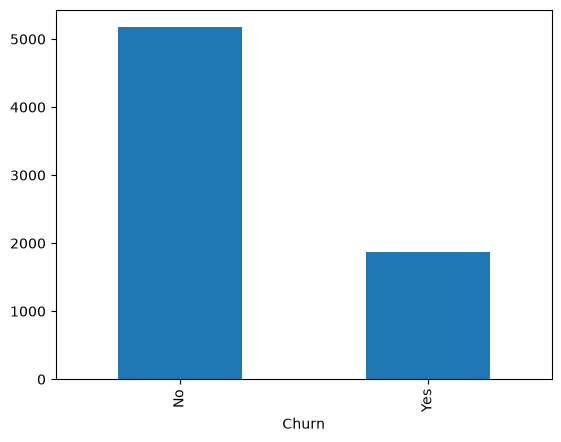

In [38]:
churn_counts = df["Churn"].value_counts()
churn_counts.plot(kind="bar")

churn_percentages = churn_counts / len(df)
combined = pd.concat(
    [churn_counts, churn_percentages], axis=1, keys=["count", "percentage"]
)
print(combined)

In [39]:
y = df["Churn"].map({"Yes": 1, "No": 0})
df = df.drop(columns=["customerID", "Churn"])

df_numeric = df.copy()
for col in df_numeric.select_dtypes(include=["string"]).columns:
    print(f"{col}: {df_numeric[col].nunique()} unique values")
    df_numeric[col] = df_numeric[col].astype("category").cat.codes

# df_numeric.head(5)
df_dummies = pd.get_dummies(df, dtype=int)
df_dummies.head(5)

gender: 2 unique values
Partner: 2 unique values
Dependents: 2 unique values
PhoneService: 2 unique values
MultipleLines: 3 unique values
InternetService: 3 unique values
OnlineSecurity: 3 unique values
OnlineBackup: 3 unique values
DeviceProtection: 3 unique values
TechSupport: 3 unique values
StreamingTV: 3 unique values
StreamingMovies: 3 unique values
Contract: 3 unique values
PaperlessBilling: 2 unique values
PaymentMethod: 4 unique values


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,1,0,0,1,1,0,...,0,1,0,0,0,1,0,0,1,0
1,0,34,56.95,1889.50,0,1,1,0,1,0,...,0,0,1,0,1,0,0,0,0,1
2,0,2,53.85,108.15,0,1,1,0,1,0,...,0,1,0,0,0,1,0,0,0,1
3,0,45,42.30,1840.75,0,1,1,0,1,0,...,0,0,1,0,1,0,1,0,0,0
4,0,2,70.70,151.65,1,0,1,0,1,0,...,0,1,0,0,0,1,0,0,1,0


In [ ]:
data = df_dummies.to_numpy()
y = y.to_numpy()
print(data.shape, y.shape)

(7043, 45)


In [ ]:
def plot(x1, x2, y, title):
    _ = plt.figure(figsize=(5, 5))
    mask_churn = y == 1
    plt.scatter(
        pca_res[mask_churn, 0],
        pca_res[mask_churn, 1],
        c="red",
        label="Churn",
        cmap="coolwarm",
        alpha=0.5,
    )
    plt.scatter(
        pca_res[~mask_churn, 0],
        pca_res[~mask_churn, 1],
        c="blue",
        label="No-Churn",
        cmap="coolwarm",
        alpha=0.5,
    )
    plt.legend()
    plt.tight_layout()
    plt.show()

In [43]:
import umap
from sklearn.decomposition import PCA

/var/folders/tz/t1tp0ycj69b_2jgm9t966fp80000gn/T/ipykernel_35415/1699689300.py:4: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(pca_res[mask_churn, 0], pca_res[mask_churn, 1], c='red', label="Churn", cmap="coolwarm", alpha=0.5)
/var/folders/tz/t1tp0ycj69b_2jgm9t966fp80000gn/T/ipykernel_35415/1699689300.py:5: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(pca_res[~mask_churn, 0], pca_res[~mask_churn, 1], c='blue', label="No-Churn", cmap="coolwarm", alpha=0.5)


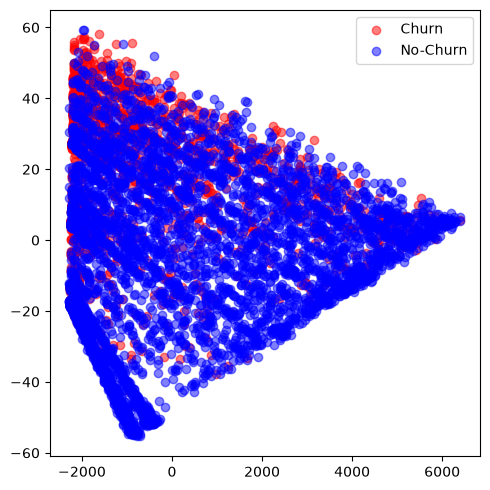

In [55]:
pca = PCA(n_components=2)
pca_res = pca.fit_transform(data)
plot(pca_res[:, 0], pca_res[:, 1], y, "PCA")

/var/folders/tz/t1tp0ycj69b_2jgm9t966fp80000gn/T/ipykernel_35415/1699689300.py:4: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(pca_res[mask_churn, 0], pca_res[mask_churn, 1], c='red', label="Churn", cmap="coolwarm", alpha=0.5)
/var/folders/tz/t1tp0ycj69b_2jgm9t966fp80000gn/T/ipykernel_35415/1699689300.py:5: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(pca_res[~mask_churn, 0], pca_res[~mask_churn, 1], c='blue', label="No-Churn", cmap="coolwarm", alpha=0.5)


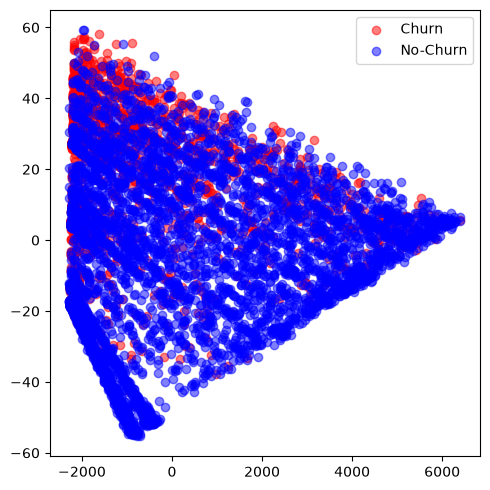

In [57]:
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="euclidean")
umap_res = umap_model.fit_transform(data)
plot(umap_res[:, 0], umap_res[:, 1], y, "UMAP")

# Inspecting preprocessed data

In [59]:
import os

In [67]:
data_dir = "../data/preprocessed/"


def inspect_data(name):
    with open(os.path.join(data_dir, f"{name}.npz"), "rb") as f:
        loaded = np.load(f)
        X = loaded["X"]
        y = loaded["y"]
        print(f"{name}:")
        print(f"\tX: {X.shape}, {X.dtype}")
        unique_labels, counts = np.unique(y, return_counts=True)
        print(
            f"\ty: {y.shape}, {y.dtype}, unique values: {[int(v) for v in unique_labels]}, counts: {[int(c) for c in counts]}"
        )


for name in ["train", "val", "test"]:
    inspect_data(name)

train:
	X: (5634, 30), float64
	y: (5634,), int64, unique values: [0, 1], counts: [4139, 1495]
val:
	X: (704, 30), float64
	y: (704,), int64, unique values: [0, 1], counts: [517, 187]
test:
	X: (705, 30), float64
	y: (705,), int64, unique values: [0, 1], counts: [518, 187]
